# 01 — Synthetic Health Demand & Surge Generation
**SurgeShield / HC-05: District Health Surge Forecast and Allocation**

### 1. Objective
Demonstrate the synthetic health demand generator across 12 interdependent geographic districts ($D_0 \dots D_{11}$) over a 42-month horizon:
- **Historical Period**: $t = 0 \dots 35$ (36 months for model calibration).
- **Evaluation Period**: $t = 36 \dots 41$ (6 months for sequential forecasting and constrained resource allocation).
- **Nominal Capacity & Global Reserve**: Nominal capacity $C_d = \lfloor 0.90 \cdot B_d \rceil$ per district and a strictly constrained global reserve of 60 units/month.
- **Unannounced Development Surge**: Transient epidemiological shock of $+35$ demand units into districts $D_2$ and $D_9$ during months $t \in [38, 40]$.

> **Zero Leakage Rule**: All generator equations and scenario logic are imported directly from `app.generator`. No future ground truth demand is used during allocation.

In [1]:
# Path configuration to import backend/app cleanly from repo root or notebooks/
import sys
from pathlib import Path

nb_dir = Path.cwd()
for candidate in [nb_dir.parent.parent / "backend", nb_dir / "backend", nb_dir]:
    if (candidate / "app").exists():
        if str(candidate.resolve()) not in sys.path:
            sys.path.insert(0, str(candidate.resolve()))
        break

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Styling for crisp, professional visual charts
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = [10, 4.5]
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)


### 2. Generator Mathematical Formulation
For district $d \in \{0 \dots 11\}$ and month $t \in [0, 41]$:
$$\mu(d, t) = B_d + A_d \sin\left(\frac{2\pi t}{12} + \frac{d\pi}{6}\right) + g_d \cdot t$$
$$\epsilon(d, t) \sim \mathcal{N}(0, 8^2)$$
$$Y(d, t) = \max\left(0, \lfloor \mu(d, t) + \epsilon(d, t) + S(d, t) \rceil\right)$$

Where $B_d \sim \text{Int}[60, 160]$, $A_d \sim \mathcal{U}[10, 40]$, $g_d \sim \mathcal{U}[-0.5, 1.5]$, and $S(d, t)$ is the unannounced surge function.

In [2]:
from app.generator import (
    DEFAULT_SEED,
    DEFAULT_NUM_DISTRICTS,
    DEFAULT_HISTORICAL_MONTHS,
    DEFAULT_FUTURE_MONTHS,
    DEFAULT_TOTAL_MONTHS,
    DEFAULT_RESERVE_CAPACITY,
    HC05DataGenerator,
    generate_development_scenario,
)

# Initialize generator with official competition development seed
print(f"Initializing HC05DataGenerator with development seed: {DEFAULT_SEED}")
generator = HC05DataGenerator(seed=DEFAULT_SEED)
scenario = generator.generate()

print(f"Generated Scenario Verification:")
print(f"  • Total Districts: {scenario.num_districts} ({scenario.districts})")
print(f"  • Historical Horizon: t = 0 to {scenario.historical_months - 1} ({scenario.historical_months} months)")
print(f"  • Evaluation Horizon: t = {scenario.historical_months} to {scenario.total_months - 1} ({scenario.future_months} months)")
print(f"  • Monthly Reserve Budget: {scenario.reserve_capacity} units")


Initializing HC05DataGenerator with development seed: 20260911
Generated Scenario Verification:
  • Total Districts: 12 (['D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11'])
  • Historical Horizon: t = 0 to 35 (36 months)
  • Evaluation Horizon: t = 36 to 41 (6 months)
  • Monthly Reserve Budget: 60 units


### 3. District Parameters & Capacity Thresholds
Let's inspect the ground truth parameters sampled for all 12 districts, including baseline demand $B_d$, seasonal amplitude $A_d$, growth rate $g_d$, and nominal district capacity $C_d$.

In [3]:
params_records = []
for d in scenario.districts:
    p = scenario.params[d]
    params_records.append({
        "District": p.district_id,
        "Base Demand (b_d)": p.b_d,
        "Seasonality Amp (a_d)": round(p.a_d, 2),
        "Phase Shift (phi_d)": f"{p.district_index}*pi/6",
        "Growth Rate (g_d)": round(p.g_d, 3),
        "Nominal Capacity (c_d)": scenario.capacities[d],
    })

df_params = pd.DataFrame(params_records)
print(df_params.to_string(index=False))


District  Base Demand (b_d)  Seasonality Amp (a_d) Phase Shift (phi_d)  Growth Rate (g_d)  Nominal Capacity (c_d)
      D0                 63                  22.76              0*pi/6              0.625                      57
      D1                126                  34.24              1*pi/6              0.956                     113
      D2                154                  32.70              2*pi/6              0.104                     139
      D3                115                  19.13              3*pi/6             -0.377                     104
      D4                 97                  28.20              4*pi/6              0.423                      87
      D5                142                  24.09              5*pi/6              1.239                     128
      D6                107                  36.33              6*pi/6              0.897                      96
      D7                 95                  10.06              7*pi/6              0.04

### 4. Demand Generation & Development Surge Analysis
The generator exports the demand matrix $D \in \mathbb{Z}_{\ge 0}^{12 \times 42}$. Let's display the monthly demand for the historical and future periods, highlighting the development surge ($+35$ in $D_2, D_9$ at $t=38, 39, 40$).

In [4]:
df_demand = scenario.to_dataframe()
# Pivot to District x Month matrix using total_demand
pivot_demand = df_demand.pivot(index="district_id", columns="month", values="total_demand")

print("Historical Period Snapshot (Months t=30..35) vs Evaluation Period (Months t=36..41):")
print(pivot_demand.loc[:, [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]])

# Verify the development surge injected into D2 and D9
d2_surge = pivot_demand.loc["D2", [37, 38, 39, 40, 41]].values
d9_surge = pivot_demand.loc["D9", [37, 38, 39, 40, 41]].values
print(f"\nSurge District D2 Demand (t=37..41): {d2_surge} (Notice jump at t=38..40)")
print(f"Surge District D9 Demand (t=37..41): {d9_surge} (Notice jump at t=38..40)")


Historical Period Snapshot (Months t=30..35) vs Evaluation Period (Months t=36..41):
month         30   31   32   33   34   35   36   37   38   39   40   41
district_id                                                            
D0            87   57   74   66   76   72   76   96  101  110  124   96
D1           157  131  136  138  135  161  178  195  185  185  182  159
D10          113  103   85   91   93   80   94  101   95  114  125  120
D11          148  128  140  103  121  106  111  151  150  159  160  173
D2           123  132  134  138  156  174  201  189  200  181  167  129
D3            90   91   89  101  100  101  117  110  120  101   88   96
D4            86   97  106  128  139  133  139  125  112   98   89   95
D5           163  186  208  213  208  205  200  193  169  159  184  176
D6           144  155  157  165  175  147  146  136  107  111  120  129
D7           120   94  100   98  109   81  100  113   81   87  102  105
D8           173  174  158  148  133  114  112   98

### 5. Visualizing Demand Dynamics & Capacity Deficits
Below we visualize:
1. Demand trajectories over time for sample districts ($D_0, D_2, D_9, D_{11}$) with the 36-month train/test split.
2. Nominal capacity vs. peak demand showing systematic capacity deficits requiring the 60-unit central reserve.

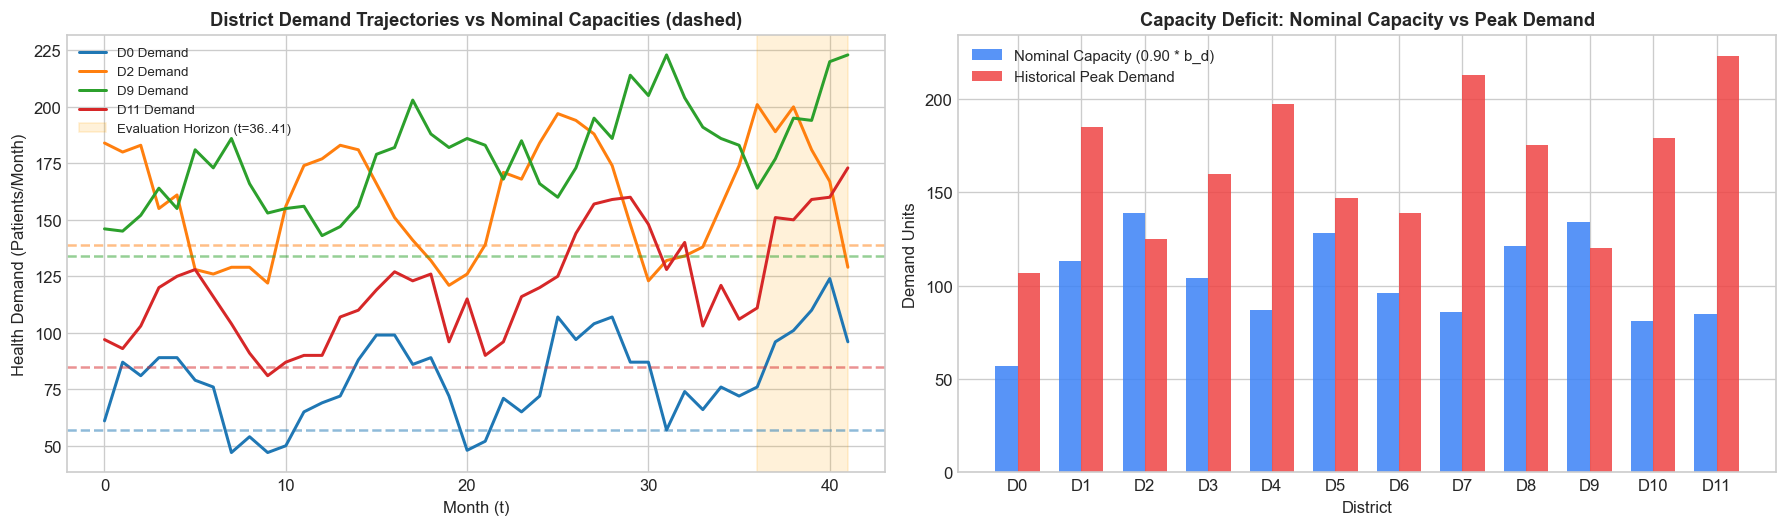

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))

# Plot 1: Demand Trajectories
months = np.arange(42)
for d in ["D0", "D2", "D9", "D11"]:
    d_dem = pivot_demand.loc[d].values
    line, = ax1.plot(months, d_dem, label=f"{d} Demand", linewidth=1.8)
    ax1.axhline(scenario.capacities[d], color=line.get_color(), linestyle="--", alpha=0.5)

ax1.axvspan(36, 41, color='orange', alpha=0.15, label="Evaluation Horizon (t=36..41)")
ax1.set_title("District Demand Trajectories vs Nominal Capacities (dashed)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Month (t)")
ax1.set_ylabel("Health Demand (Patients/Month)")
ax1.legend(loc="upper left", fontsize=8)

# Plot 2: Peak Demand vs Capacity
cap_series = [scenario.capacities[f"D{i}"] for i in range(12)]
peak_dem = pivot_demand.iloc[:, :36].max(axis=1).values
x = np.arange(12)
width = 0.35

ax2.bar(x - width/2, cap_series, width, label="Nominal Capacity (0.90 * b_d)", color="#3b82f6", alpha=0.85)
ax2.bar(x + width/2, peak_dem, width, label="Historical Peak Demand", color="#ef4444", alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels([f"D{i}" for i in range(12)])
ax2.set_title("Capacity Deficit: Nominal Capacity vs Peak Demand", fontsize=11, fontweight="bold")
ax2.set_xlabel("District")
ax2.set_ylabel("Demand Units")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


### 6. Interpretation & Mathematical Invariants
- **Reproducibility**: The generator uses `PCG64(seed=20260911)` ensuring bitwise deterministic scenarios across platforms.
- **Structural Deficits**: Nominal capacity is capped at 90% of baseline ($C_d = \lfloor 0.90 \cdot B_d \rceil$), meaning during seasonal peaks all districts face shortfalls without the 60-unit central reserve.
- **Online Decoupling**: Crucially, future demands $D(d, t)$ for $t \ge 36$ are unknown to the forecaster and allocator until the simulation sequentially steps through time.